# Atrasando a entrada


1. Gerar modelo GPR 
2. Gerar posição das amostras virtuais

- 3 entradas:
    - Wd
    - We
    - thetaLag <- theta(Wd,We) deslocado 1 time step para trás
- 1 saída:
    - theta(Wd,We)


#  Gerando Amostras Virtuais

In [ ]:
# === IMPORTS ===
import numpy as np
import pandas as pd
from scipy.spatial import Delaunay
import plotly.graph_objs as go
import plotly.figure_factory as ff
import plotly.offline as py
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared, DotProduct, WhiteKernel, ConstantKernel as C
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error

In [36]:

def PrintInputSpace(original_samples_x, virtual_samples_x):
    """
    Gera e salva um gráfico do espaço de entrada com amostras originais, virtuais e de teste.
    A fonte da figura é definida como Times New Roman, 12.
    """

    fig = go.Figure()

    # Limites dos eixos com margem
    # Combina todos os dados para encontrar os limites globais
    all_x1 = np.concatenate([original_samples_x[:, 0], virtual_samples_x[:, 0]])
    all_x2 = np.concatenate([original_samples_x[:, 1], virtual_samples_x[:, 1]])
    
    x1_min, x1_max = all_x1.min(), all_x1.max()
    x2_min, x2_max = all_x2.min(), all_x2.max()

    margin = 0.05  # margem visual
    x1_range = [x1_min - margin, x1_max + margin]
    x2_range = [x2_min - margin, x2_max + margin]

    # Amostras originais
    fig.add_trace(go.Scatter(
        x=original_samples_x[:, 0],
        y=original_samples_x[:, 1],
        mode='markers',
        name='Amostras Originais',
        marker=dict(color='gray', size=8, opacity=0.8, symbol='circle')
    ))

    # Amostras virtuais
    fig.add_trace(go.Scatter(
        x=virtual_samples_x[:, 0],
        y=virtual_samples_x[:, 1],
        mode='markers',
        name='Amostras Virtuais',
        marker=dict(color='blue', size=8, opacity=0.8, symbol='circle')
    ))

    x_ticks = np.round(np.linspace(*x1_range, num=5), 1)
    y_ticks = np.round(np.linspace(*x2_range, num=5), 1)

    x_tickvals = x_ticks
    x_ticktext = [f"{v:.1f}".replace('.', ',') for v in x_ticks]

    y_tickvals = y_ticks
    y_ticktext = [f"{v:.1f}".replace('.', ',') for v in y_ticks]


    fig.update_layout(
        font=dict(
            family="Times New Roman",
            size=20,
            color="black"
        ),
        xaxis=dict(
            title=dict(
                text=r"<b>$x_1$</b>",
                font=dict(family="Times New Roman", size=20, color="black")
            ),
            range=x1_range,
            tickvals=x_tickvals,
            ticktext=x_ticktext,
            showgrid=True,
            gridwidth=1,
            gridcolor='lightgray',
            zeroline=False
        ),
        yaxis=dict(
            title=dict(
                text=r"<b>$x_2$</b>",
                font=dict(family="Times New Roman", size=20, color="black")
            ),
            range=x2_range,
            tickvals=y_tickvals,
            ticktext=y_ticktext,
            showgrid=True,
            gridwidth=1,
            gridcolor='lightgray',
            zeroline=False
        ),
        legend=dict(
            orientation='h',     # horizontal
            x=0.5,
            y=-0.2,
            xanchor='center',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='lightgray',
            borderwidth=1
        ),
        template='plotly_white',
        width=400,
        height=400,
        margin=dict(b=100)  # espaço extra na base
    )
    
    # Exporta a imagem para PDF
    output_path = f"./figs/InputSpace.pdf"
    fig.write_image(output_path, format='pdf')
    print(f"Figura salva em: {output_path}")
   

In [37]:


PREDICTORS = ["Wd", "We", "thetaLag"]
TARGET = "theta(Wd,We)"

KERNELS = [
    ("RBF",                   C(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e+6))),
    ("Matern_0.5",            C(1.0) * Matern(length_scale=1.0, nu=0.5, length_scale_bounds=(1e-6, 1e+6))),
    ("RationalQuadratic",     C(1.0) * RationalQuadratic(length_scale=1.0, alpha=0.1, length_scale_bounds=(1e-6, 1e+6))),
    ("DotProduct",            C(1.0) * DotProduct() + WhiteKernel()),
    ("ExpSineSquared",        C(1.0) * ExpSineSquared(length_scale=1.0, periodicity=3.0, length_scale_bounds=(1e-6, 1e+6)))

]


TRAINFILES = ["DataSpline1"]
TESTFILES = ["DataSpline2", "DataSpline3", "DataSpline4"]


def GetTrainData(file):
    TrainData = pd.read_csv(f"../Dados/{file}.csv")
    TrainData["thetaLag"] = TrainData["theta(Wd,We)"].shift(1)
    TrainData = TrainData.iloc[1:]
    return TrainData
    
def GetTestData(file):
    TestData = pd.read_csv(f"../Dados/{file}.csv")
    TestData.index = (np.arange(0, len(TestData), 1).astype(float) * 0.07).round(5)
    TestData["thetaLag"] = TestData["theta(Wd,We)"].shift(1)
    TestData = TestData.iloc[1:]
    
    test_samples_x = np.array(TestData[PREDICTORS])
    test_samples_y = np.array(TestData[TARGET])
    test_time = TestData.head(np.size(test_samples_y)).index
    return test_samples_x, test_samples_y, test_time


class GprVsg3D:
    def __init__(self):        
        TrainData = GetTrainData(TRAINFILES[0])
        self.train_samples_x = np.array(TrainData[PREDICTORS])
        self.train_samples_y = np.array(TrainData[TARGET])
        self.train_time = TrainData.head(np.size(self.train_samples_y)).index
        self.model = None
        
        self.d = self.train_samples_x.shape[1]

        self.virtual_samples_x = []
        self.virtual_samples_y = []

    def BuildModel(self, kernel):
        self.model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2,
                                              alpha=1e-7, normalize_y=True)
        self.model.fit(self.train_samples_x, self.train_samples_y)
    
    def Evaluate(self, kernel_name):
        colors = plt.cm.tab10.colors  

        # subplots empilhados (treino + n testes)
        fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=False)
        axes = axes.flatten()   # transforma em array 1D com 4 posições

        # === Previsão treino ===
        self.train_pred = self.model.predict(self.train_samples_x)
        
        metrics = {
            'r2_training': r2_score(self.train_samples_y, self.train_pred),
            'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
            'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
            'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred)
        }
        
        ax = axes[0]
        ax.plot(self.train_time, self.train_pred, marker="o", linewidth=2,
                label="train_pred", color=colors[0])
        ax.plot(self.train_time, self.train_samples_y, marker="o", linewidth=2,
                label="train_orig", color=colors[1])
        ax.set_title("Dados de Treinamento", fontsize=13)
        ax.set_xlabel("Tempo (s)", fontsize=12)
        ax.set_ylabel("Velocidade Angular", fontsize=12)
        ax.legend()
        ax.grid(True)
        
        # === Loop nos testes ===
        for i, file in enumerate(TESTFILES):
            test_samples_x, test_samples_y, test_time = GetTestData(file)
            test_pred = self.model.predict(test_samples_x)
            
            metrics.update({
                f'r2_test{i+1}': r2_score(test_samples_y, test_pred),
                f'mse_test{i+1}': mean_squared_error(test_samples_y, test_pred),
                f'mape_test{i+1}': mean_absolute_percentage_error(test_samples_y, test_pred),
                f'rmse_test{i+1}': root_mean_squared_error(test_samples_y, test_pred)
            })
            
            ax = axes[i+1]  # subplots [1], [2], [3] para os testes
            ax.plot(test_time, test_pred, marker="o", linewidth=2,
                    label=f"test_pred_{i+1}", color=colors[2*i % len(colors)])
            ax.plot(test_time, test_samples_y, marker="o", linewidth=2,
                    label=f"test_orig_{i+1}", color=colors[(2*i+1) % len(colors)])
            ax.set_title(f"Dados de Teste {i+1} ({file})", fontsize=13)
            ax.set_xlabel("Tempo (s)", fontsize=12)
            ax.set_ylabel("Velocidade Angular", fontsize=12)
            ax.legend()
            ax.grid(True)

        # Título geral
        fig.suptitle(f"Resultados do modelo GPR: {kernel_name}", fontsize=15)
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.savefig(f"content/figs/{kernel_name}.pdf", format="pdf", dpi=600)
        plt.show()
        
        return metrics 
                 
    def EvalModel(self, excel_path):
        results = []  # lista para armazenar todas as métricas
        
        for name, kernel in KERNELS:
            self.BuildModel(kernel=kernel)
            metrics = self.Evaluate(kernel_name=name)
            display(metrics)
            metrics["Kernel"] = name  # adiciona o nome do kernel como coluna
            results.append(metrics)

        # cria um único DataFrame com todos os resultados
        df = pd.DataFrame(results)

        # reorganiza para que "Kernel" fique como primeira coluna
        cols = ["Kernel"] + [c for c in df.columns if c != "Kernel"]
        df = df[cols]

        # salva em uma única planilha
        with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
            df.to_excel(writer, sheet_name="Resultados", index=False)
            
    def ComputeProjection(self):
        projections = []
        for m in range(self.d):
            x = self.train_samples_x[:, m]
            v = self.train_samples_x[:, m]
            xm_proj = (np.dot(x, v) / np.linalg.norm(v) ** 2) * v
            projections.append(np.sort(xm_proj))
        return projections

    def SetInputSpace(self):
        projections = self.ComputeProjection()
        avg_dists = [np.mean(np.diff(proj)) for proj in projections]

        Q_alpha = np.quantile(projections, [0.025, 0.25, 0.5, 0.75, 0.975], axis=1, method="hazen").T
        for m in range(self.d):
            for i in range(len(projections[m]) - 1):
                dist = projections[m][i + 1] - projections[m][i]
                if dist > avg_dists[m]:
                    G = (projections[m][i] + projections[m][i + 1]) / 2
                    for q in range(self.d):
                        if q != m:
                            for quantile in Q_alpha[q]:
                                tilde_q = np.zeros(self.d)
                                tilde_q[m] = G
                                tilde_q[q] = quantile
                                self.virtual_samples_x.append(tilde_q)
        self.virtual_samples_x = np.array(self.virtual_samples_x)

    def ComputeY(self):
        self.virtual_samples_y = self.model.predict(self.virtual_samples_x)
        self.virtual_samples_df = pd.DataFrame({
            "Wd": self.virtual_samples_x[:, 0],
            "We": self.virtual_samples_x[:, 1],
            "theta(Wd,We)": self.virtual_samples_y
        })
        return self.virtual_samples_df
    
    
    def GetVirtualSamples(self):
        self.SetInputSpace()
        PrintInputSpace(self.train_samples_x, self.virtual_samples_x)

        for name, kernel in KERNELS:
            self.BuildModel(kernel=kernel)
            self.ComputeY()
            
            self.virtual_samples_df.to_excel(f"./content/VirtualSamples/virtual_samples_{name}.xlsx", index=False)

In [38]:
Vsg = GprVsg3D()

In [39]:
Vsg.GetVirtualSamples()

NameError: name 'go' is not defined

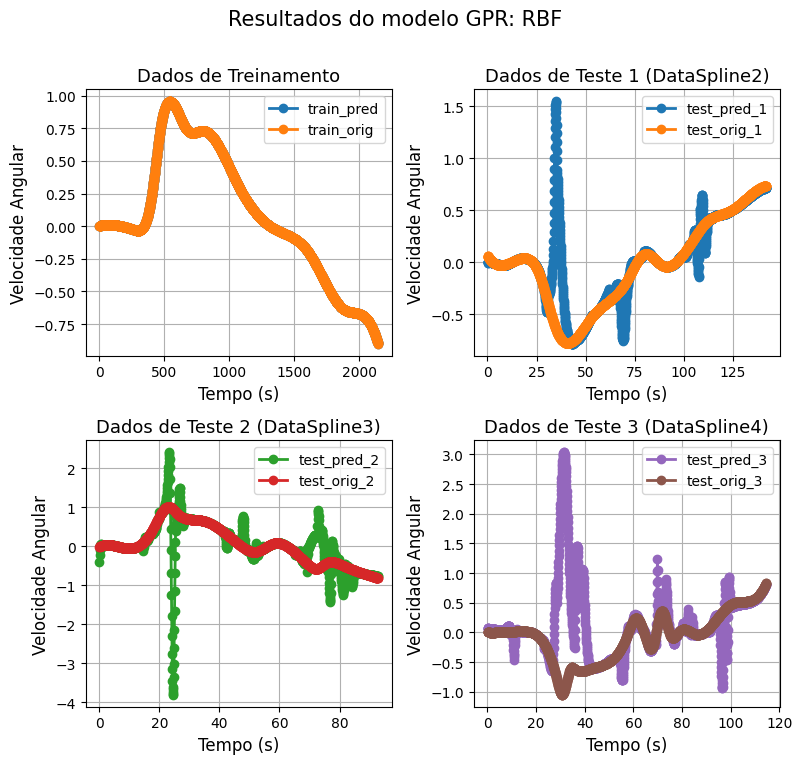

{'r2_training': 0.9999999945676143,
 'mse_training': 1.3105083324386859e-09,
 'mape_training': 0.001221633090926618,
 'rmse_training': 3.6200943805910445e-05,
 'r2_test1': 0.5366102920067006,
 'mse_test1': 0.07643045204190602,
 'mape_test1': 0.3288748127421181,
 'rmse_test1': 0.27646057954418385,
 'r2_test2': -0.18342308882097247,
 'mse_test2': 0.27287806146702165,
 'mape_test2': 1.0076423515204822,
 'rmse_test2': 0.5223773171444388,
 'r2_test3': -2.7604477768891127,
 'mse_test3': 0.6010600434209007,
 'mape_test3': 15.447477303276093,
 'rmse_test3': 0.7752806223690236}

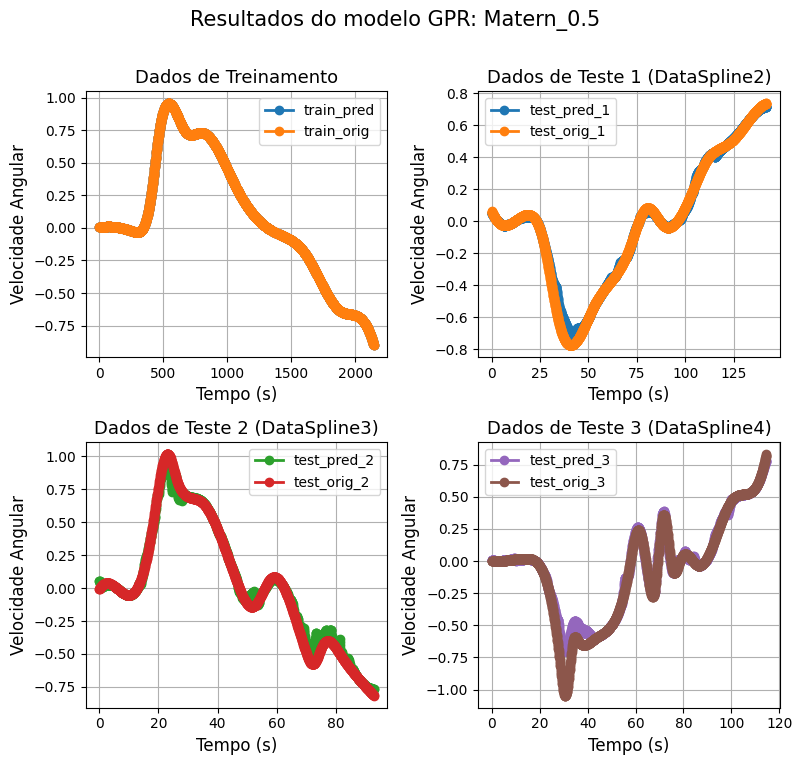

{'r2_training': 0.9999999999945064,
 'mse_training': 1.3252865715618518e-12,
 'mape_training': 5.721957828272864e-06,
 'rmse_training': 1.151210915324317e-06,
 'r2_test1': 0.9942230686112979,
 'mse_test1': 0.0009528340181866146,
 'mape_test1': 0.1353390603448309,
 'rmse_test1': 0.0308680096246359,
 'r2_test2': 0.9896442632796739,
 'mse_test2': 0.002387863975275977,
 'mape_test2': 0.2695423298013378,
 'rmse_test2': 0.04886577509132519,
 'r2_test3': 0.9666479330672657,
 'mse_test3': 0.005330906314393743,
 'mape_test3': 1.4203817237059455,
 'rmse_test3': 0.0730130557804133}

d:\Users\sarah\Educ\IC-2025.1\tf-env\lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
d:\Users\sarah\Educ\IC-2025.1\tf-env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


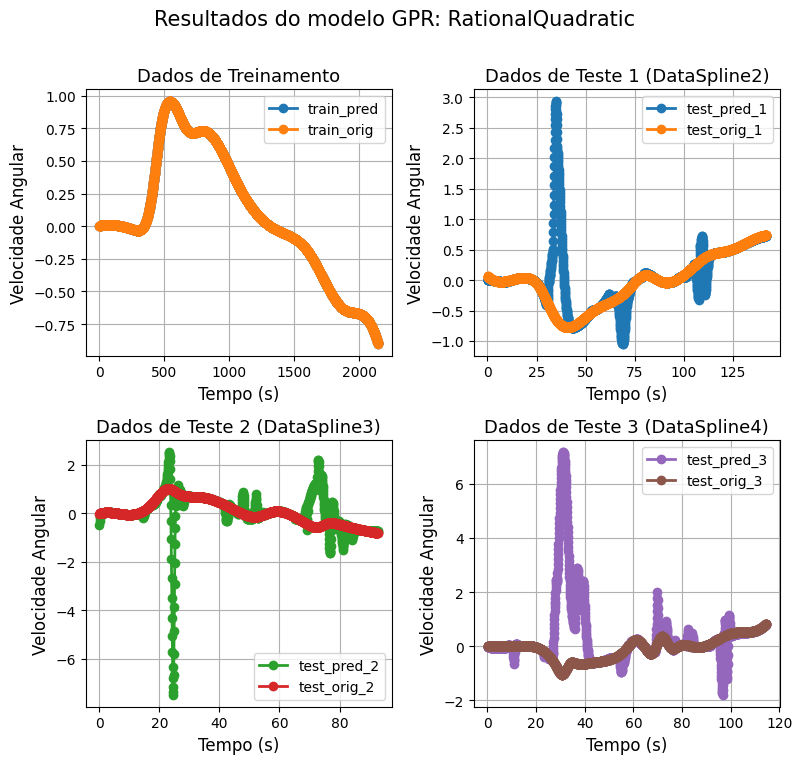

{'r2_training': 0.9999999939186454,
 'mse_training': 1.4670655606370499e-09,
 'mape_training': 0.0018492494458078746,
 'rmse_training': 3.830229184575056e-05,
 'r2_test1': -0.5061082680967399,
 'mse_test1': 0.2484140967506135,
 'mape_test1': 0.436280565219509,
 'rmse_test1': 0.49841157365235156,
 'r2_test2': -2.160888599593217,
 'mse_test2': 0.7288493538093289,
 'mape_test2': 1.2013902352550172,
 'rmse_test2': 0.8537267442275245,
 'r2_test3': -13.696462295327029,
 'mse_test3': 2.3490437281568908,
 'mape_test3': 15.837290334085427,
 'rmse_test3': 1.5326590384547016}

d:\Users\sarah\Educ\IC-2025.1\tf-env\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


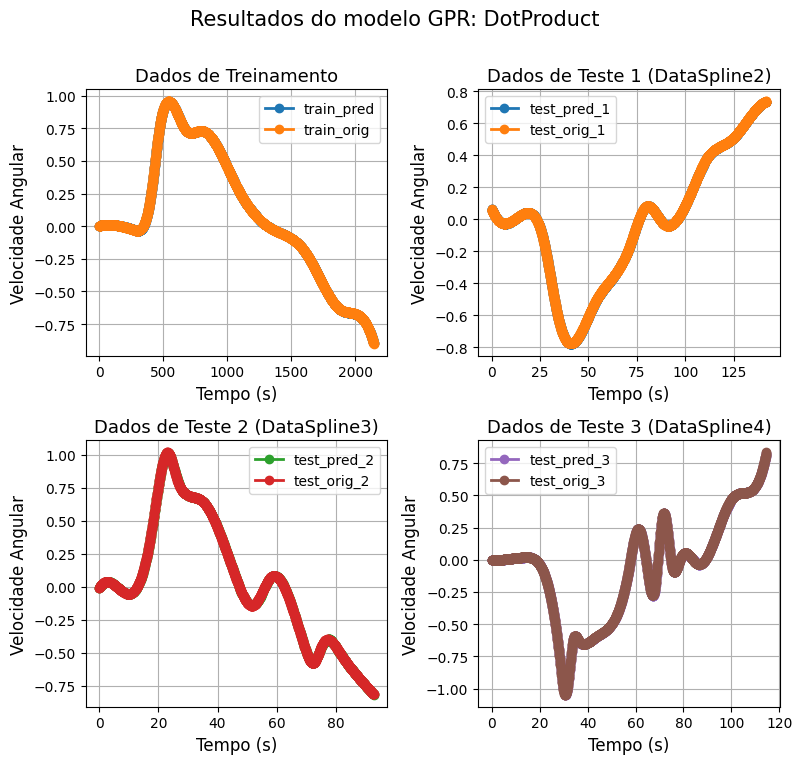

{'r2_training': 0.9999904876486104,
 'mse_training': 2.2947589766742233e-06,
 'mape_training': 0.04363193073187215,
 'rmse_training': 0.001514846189114335,
 'r2_test1': 0.9999809419838835,
 'mse_test1': 3.143386142759769e-06,
 'mape_test1': 0.050649881198384684,
 'rmse_test1': 0.0017729597126725043,
 'r2_test2': 0.9999550261273692,
 'mse_test2': 1.03702414597858e-05,
 'mape_test2': 0.04468477863364548,
 'rmse_test2': 0.0032202859282656564,
 'r2_test3': 0.999909968599792,
 'mse_test3': 1.4390381286735274e-05,
 'mape_test3': 0.17800812373381825,
 'rmse_test3': 0.003793465603736941}

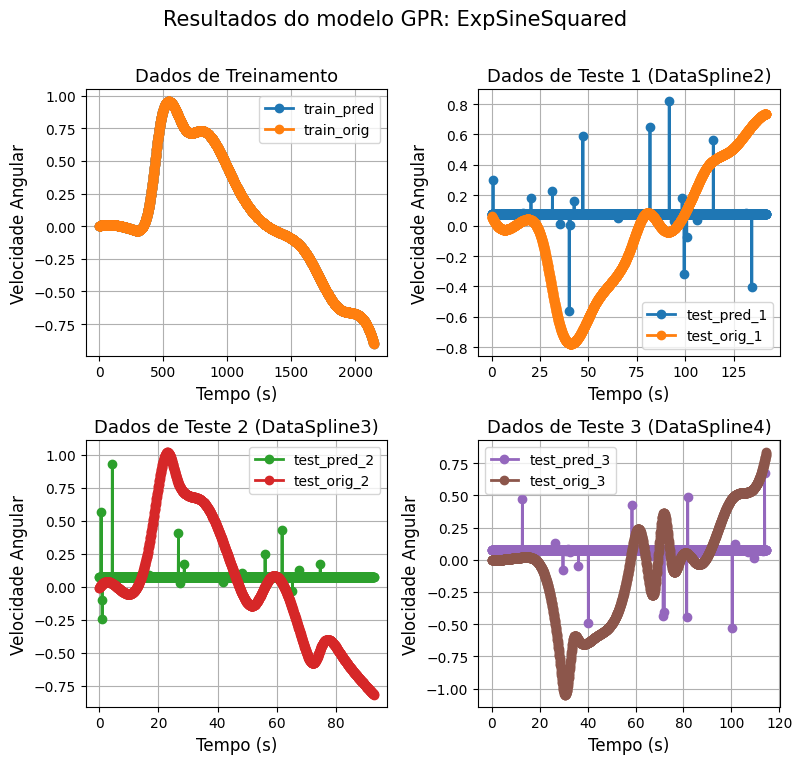

{'r2_training': 1.0,
 'mse_training': 6.596112649789625e-18,
 'mape_training': 2.8767920586883683e-09,
 'rmse_training': 2.5682898297874455e-09,
 'r2_test1': -0.05991492523702058,
 'mse_test1': 0.17481997434220078,
 'mape_test1': 3.3242188432324795,
 'rmse_test1': 0.4181147860841575,
 'r2_test2': -0.010668935678977975,
 'mse_test2': 0.23304377154562914,
 'mape_test2': 2.3865280786291,
 'rmse_test2': 0.4827460735683193,
 'r2_test3': -0.127410666666409,
 'mse_test3': 0.18020234409964006,
 'mape_test3': 22.213298615732214,
 'rmse_test3': 0.4245024665412912}

In [ ]:
# Vsg.EvalModel("./content/GprMetrics.xlsx")